## Nội dung

- Feature engineering
- Phân cụm: KMeans, DBSCAN
- Kết hợp phân cụm và phân tích mô tả
- Kết hợp PCA và phân cụm
- Tập dữ liệu:
   1. Customer Personality Analysis (nguồn: https://www.kaggle.com/datasets/imakash3011/customer-personality-analysis)
   2. Taxi geolocation (nguồn: https://www.coursera.org/projects/clustering-geolocation-data-intelligently-python)

#### Cài đặt thư viện

In [1]:
!pip install folium
!pip install kneed
!pip install yellowbrick
!pip install kneed


   ---------------------------------------- 0/3 [xyzservices]
   ---------------------------------------- 0/3 [xyzservices]
   ------------- -------------------------- 1/3 [branca]
   ------------- -------------------------- 1/3 [branca]
   ------------- -------------------------- 1/3 [branca]
   ------------- -------------------------- 1/3 [branca]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -------------------------- ------------- 2/3 [folium]
   -----------------

### A. Customer Personality Analysis

#### A1. Đọc dữ liệu

In [2]:
import numpy as np
import pandas as pd

In [3]:
pd.set_option('display.max_columns', None)
customer_data = pd.read_csv('data/marketing_campaign.csv',
                           delimiter='\t', index_col='ID')
customer_data.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


#### A2. Làm sạch
- Làm sạch dữ liệu.
- Trích xuất đặc trưng (đọc thêm: https://machinelearningcoban.com/general/2017/02/06/featureengineering/)

In [4]:
customer_data.info()

<class 'pandas.DataFrame'>
Index: 2240 entries, 5524 to 9405
Data columns (total 28 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year_Birth           2240 non-null   int64  
 1   Education            2240 non-null   str    
 2   Marital_Status       2240 non-null   str    
 3   Income               2216 non-null   float64
 4   Kidhome              2240 non-null   int64  
 5   Teenhome             2240 non-null   int64  
 6   Dt_Customer          2240 non-null   str    
 7   Recency              2240 non-null   int64  
 8   MntWines             2240 non-null   int64  
 9   MntFruits            2240 non-null   int64  
 10  MntMeatProducts      2240 non-null   int64  
 11  MntFishProducts      2240 non-null   int64  
 12  MntSweetProducts     2240 non-null   int64  
 13  MntGoldProds         2240 non-null   int64  
 14  NumDealsPurchases    2240 non-null   int64  
 15  NumWebPurchases      2240 non-null   int64  
 16  N

Dữ liệu khá sạch và chỉ có 1 số lượng nhỏ income bị thiếu dữ liệu, có thể xử lý bằng cách thêm vào mean. Mã hoá 1 số đặc trưng kiểu loại.

In [5]:
# TODO, Xử lý dữ liệu khuyết cho Income bằng cách thêm mean
customer_data['Income'].fillna(customer_data['Income'].mean(), inplace=True)

C:\Users\MR BAO\AppData\Local\Temp\ipykernel_11948\2058737177.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  customer_data['Income'].fillna(customer_data['Income'].mean(), inplace=True)


ID
5524     58138.0
2174     46344.0
4141     71613.0
6182     26646.0
5324     58293.0
          ...   
10870    61223.0
4001     64014.0
7270     56981.0
8235     69245.0
9405     52869.0
Name: Income, Length: 2240, dtype: float64

#### A3. Feature engineering

In [6]:
import datetime

Đầu tiên là dữ liệu liên quan ngày tháng.

- `Year_Birth` không phải là đặc trưng lý tưởng cho bài toán này, ta sẽ chuyển nó sang thành tuổi `Age` (tính từ hiện tại)

In [7]:
# Trích xuất tuổi từ đặc trưng năm sinh
# hint: 2022 - x
customer_data['Age'] = 2022 - customer_data['Year_Birth']

- `Days_Since_Customer`, tương tự như `Year_Birth`, nên được chuyển thành số ngày đã tham gia `Enroll_days`.

In [9]:
# Đặc trưng 'Days_Since_Customer' ~ ngày tham gia, biến đổi thành số lượng ngày đã tham gia
customer_data['Dt_Customer'] = pd.to_datetime(customer_data['Dt_Customer'],  format='mixed')
now = datetime.datetime.now()
customer_data['Enroll_days'] = (now - customer_data['Dt_Customer']).dt.days

- Các đặc trưng `Marital_Status`, `Kidhome`, `Teenhome` có thể được gom lại 1 thuộc tính duy nhất --> cô động hơn

In [11]:
# Tạo ra đặc trưng Fam_size (số người trong gia đình)
# bằng cách gộp các đặc trưng: Martial_Status, Kidhome, Teenhome
marital_map = {
    'Absurd': 1, 'Alone': 1,
    'YOLO': 1, 'Single': 1,
    'Married': 2, 'Together': 2,
    'Widow': 1, 'Divorced': 1
} # married/together->2 người, khác-> 1 người
customer_data['Marital_Status'] = customer_data['Marital_Status'].map(marital_map)
customer_data['Fam_Size'] = customer_data['Marital_Status'] + customer_data['Kidhome'] + customer_data['Teenhome']

- Gom các đặc trưng `AcceptedCmpX` thành 1 đặc trưng `Num_Accepted` (tổng)
- Làm tương tự cho các đặc trưng MntX, gom thành đặc trưng `MntTotal`

In [13]:
cmp_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
customer_data['Num_Accepted'] = customer_data[cmp_cols].sum(axis=1)

In [14]:
# Có thể gộp các đặc trưng MntXXX thành 1 thuộc tính duy nhất (tính tổng)
mnt_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
customer_data['MntTotal'] = customer_data[mnt_cols].sum(axis=1)

#### A4. Phân tích EDA

In [15]:
customer_data.describe()

,Year_Birth,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,1968.805804,1.644643,52247.251354,0.444196,0.506250,2013-07-11 22:57:38.571428,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107,53.194196,4835.043304,2.595089,0.297768,605.798214
min,1893.000000,1.000000,1730.000000,0.000000,0.000000,2012-01-08 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,26.000000,4323.000000,1.000000,0.000000,5.000000
25%,1959.000000,1.000000,35303.000000,0.000000,0.000000,2013-01-19 18:00:00,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,45.000000,4663.750000,2.000000,0.000000,68.750000
50%,1970.000000,2.000000,51381.500000,0.000000,0.000000,2013-07-11 00:00:00,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,52.000000,4836.000000,3.000000,0.000000,396.000000
75%,1977.000000,2.000000,68522.000000,1.000000,1.000000,2013-12-30 06:00:00,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000,63.000000,5008.250000,3.000000,0.000000,1045.500000
max,1996.000000,2.000000,666666.000000,2.000000,2.000000,2014-12-06 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000,129.000000,5386.000000,5.000000,4.000000,2525.000000
std,11.984069,0.478728,25173.076661,0.538398,0.544538,NaN,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274,11.984069,232.229893,0.906959,0.678381,602.249288


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

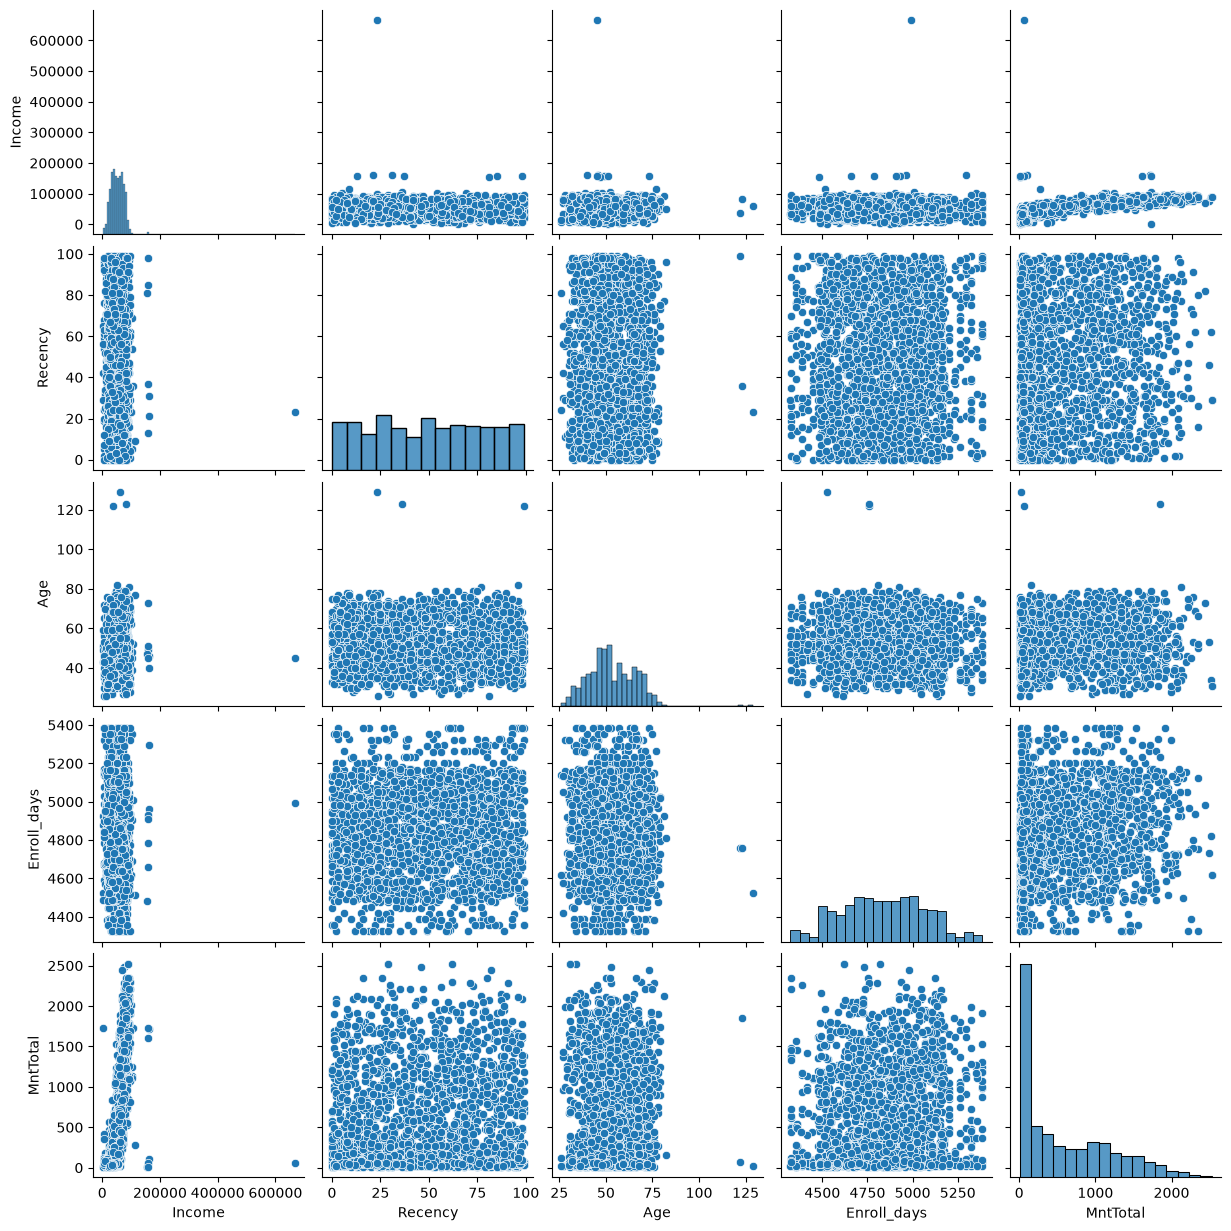

In [17]:
plot_cols = ['Income', 'Recency', 'Age', 'Enroll_days', 'MntTotal']
# TODO - vẽ pair plot
sns.pairplot(customer_data[plot_cols])
plt.show()

In [19]:
# TODO - xử lý nhiễu (nếu có)
from sklearn.preprocessing import StandardScaler

if 'df' not in locals() and 'df' not in globals():
    df = customer_data.copy()
    cols_to_drop = [
        'Dt_Customer', 'Year_Birth', 'Kidhome', 'Teenhome', 'Marital_Status',
        'Z_CostContact', 'Z_Revenue', 'MntWines', 'MntFruits', 'MntMeatProducts',
        'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
        'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5',
        'Complain', 'Response', 'Education', 'Num_Accepted'
    ]
    existing_cols = [c for c in cols_to_drop if c in df.columns]
    df.drop(existing_cols, axis=1, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)
print("Hoàn tất chuẩn hóa! Kích thước df:", df.shape)

Hoàn tất chuẩn hóa! Kích thước df: (2240, 11)


In [20]:
import copy
df = customer_data.copy()

# Drop các cột không quan trọng
df.drop([
    'Dt_Customer', 'Year_Birth',
    'Kidhome', 'Teenhome', 'Marital_Status',
    'Z_CostContact', 'Z_Revenue',
    'MntWines', 'MntFruits', 'MntMeatProducts',
    'MntFishProducts', 'MntSweetProducts', 'MntGoldProds',
    'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3',
    'AcceptedCmp4','AcceptedCmp5',
    'Complain', 'Response', 'Education', 'Num_Accepted'
], axis=1, inplace=True)

#### A5. Tiền xử lý

**Mã hoá đặc trưng kiểu loại**

In [21]:
# TODO
categorical_cols = df.select_dtypes(include=['object']).columns
if len(categorical_cols) > 0:
    df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

**Chuẩn hoá các thuộc tính kiểu số**

In [22]:
# TODO
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df = pd.DataFrame(X_scaled, columns=df.columns, index=df.index)

In [23]:
df.describe() # --> Kiểm tra mean và std có gần với giá trị (0, 1)?

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Age,Enroll_days,Fam_Size,MntTotal
count,2.216000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03,2.240000e+03
mean,4.889791e-17,-3.172066e-18,-9.833404e-17,-5.709718e-17,9.516197e-18,7.612958e-17,-6.344132e-17,-1.681195e-16,-2.268027e-16,-7.612958e-17,3.647876e-17
std,1.000226e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00,1.000223e+00
min,-2.007250e+00,-1.696001e+00,-1.203537e+00,-1.470368e+00,-9.108985e-01,-1.781466e+00,-2.191381e+00,-2.269702e+00,-2.205391e+00,-1.759115e+00,-9.978133e-01
25%,-6.732620e-01,-8.671566e-01,-6.858866e-01,-7.504503e-01,-9.108985e-01,-8.584551e-01,-9.548307e-01,-6.839101e-01,-7.377670e-01,-6.562832e-01,-8.919365e-01
50%,-3.439972e-02,-3.777284e-03,-1.682363e-01,-3.053224e-02,-2.265407e-01,-2.431145e-01,2.817201e-01,-9.967091e-02,4.120529e-03,4.465483e-01,-3.484355e-01
75%,6.466600e-01,8.596020e-01,3.494139e-01,6.893858e-01,4.578170e-01,6.798964e-01,6.939037e-01,8.184192e-01,7.460081e-01,4.465483e-01,7.302623e-01
max,2.441328e+01,1.722981e+00,6.561217e+00,8.248526e+00,8.670110e+00,2.218248e+00,6.052291e+00,6.326960e+00,2.372992e+00,2.652211e+00,3.187435e+00


#### A6. Phân cụm KMeans

In [24]:
from sklearn.cluster import KMeans

Phương pháp Elbow: ước lượng số cụm

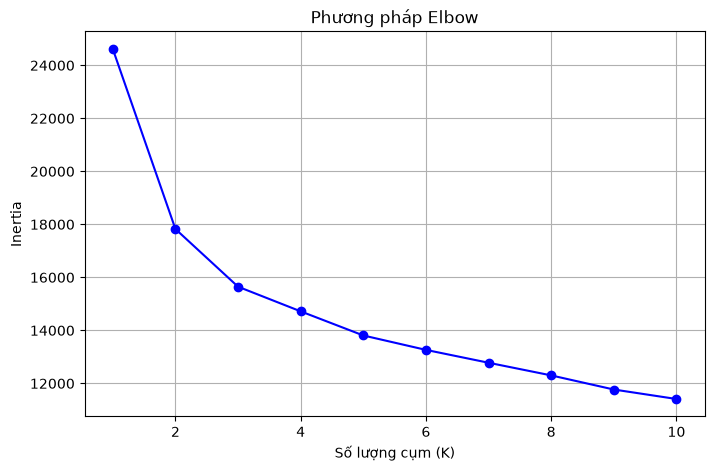

In [28]:
# TODO - vẽ biểu đồ elbow để ước lượng số cụm
inertias = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker='o', color='b')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Inertia')
plt.title('Phương pháp Elbow')
plt.grid(True)
plt.show()

Sử dụng thư viện yellowbrick

In [32]:
!pip install yellowbrick

In [34]:
from yellowbrick.cluster import KElbowVisualizer

ModuleNotFoundError: No module named 'yellowbrick'

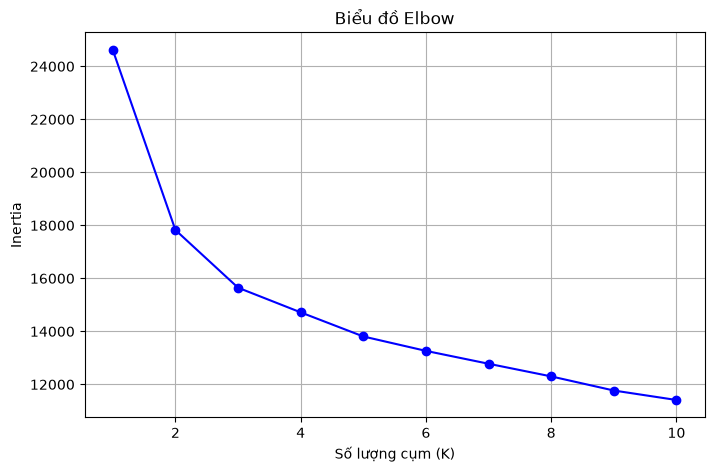

In [35]:
# TODO
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    kmeans.fit(df)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='b')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Inertia')
plt.title('Biểu đồ Elbow')
plt.grid(True)
plt.show()

**Phân cụm từ kết quả của phương pháp Elbow**

In [36]:
# TODO
k = 4
kmean = KMeans(n_clusters=k, n_init=20, random_state=42)
kmean.fit(df)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",20
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary <random_state>`.",42
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'
Name,Type,Value
"cluster_centers_ cluster_centers_: ndarray of shape (n_clusters, n_features)Coordinates of cluster centers. If the algorithm stops before fullyconverging (see ``tol`` and ``max_iter``), these will not beconsistent with ``labels_``.","ndarray[float64](4, 11)","[[-0

**Sử dụng PCA giảm số chiều dữ liệu --> trực quan hoá kết quả phân cụm**

In [37]:
from sklearn.decomposition import PCA

In [38]:
# Biến đổi dữ liệu sang không gian 2 chiều pca
# TODO
pca = PCA(n_components=2)
scores = pca.fit_transform(df)


**Trực quan hoá kết quả phân cụm**

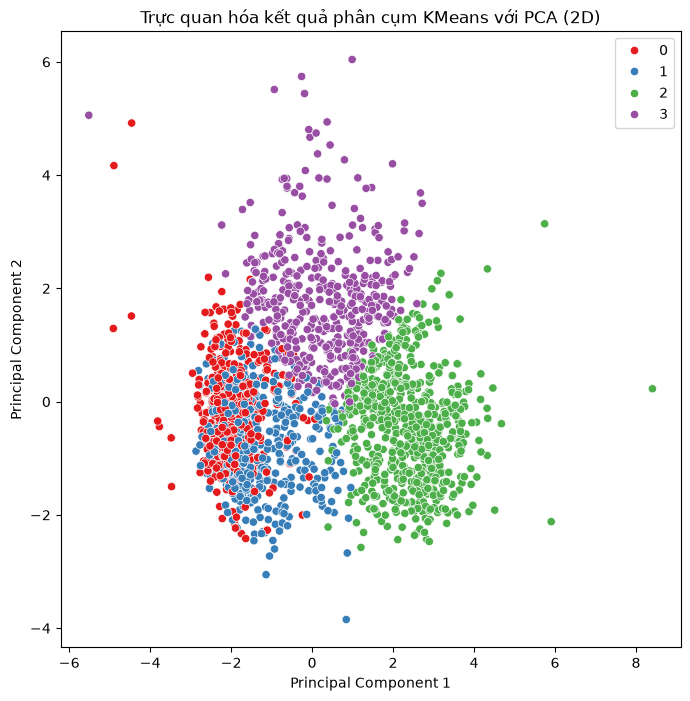

In [43]:
def visualize_cluster_result(scores, labels):
    '''
    Args:
        scores: biến đổi pca 2d
        labels: nhãn của từng điểm dữ liệu trong scores (chính là label của kết quả phân cụm)
    '''
    fig1, axes = plt.subplots(figsize=(8, 8))
    scat_1 = sns.scatterplot(
        x=scores[:, 0],
        y=scores[:, 1],
        hue=labels, 
        ax=axes,
        palette='Set1', 
        legend='full'
    )
    plt.title('Trực quan hóa kết quả phân cụm KMeans với PCA (2D)')
    plt.xlabel('Principal Component 1')
    plt.ylabel('Principal Component 2')
    plt.show()

# Gọi hàm để hiển thị biểu đồ sau khi đã có scores và kmean.labels_
visualize_cluster_result(scores, kmean.labels_)

#### Phân tích kết quả phân cụm (KMeans)

In [44]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_df = customer_data.copy()
kmean_df['Cluster'] = kmean.labels_
kmean_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5294,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4448,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4795,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4388,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4644,3,0,422,3


In [ ]:
def visualize_cluster_distribution(labels):
    '''
    Args:
        labels: kết quả phân cụm (danh sách nhãn)
    '''
    ulabels, count = np.unique(labels, return_counts=True)
    plt.figure(figsize=(6,4))

    colors = sns.color_palette('Set2')[0:5]
    
    labels = [f'Cluster {i+1}' for i in range(len(ulabels))]
    plt.pie(count, 
            explode=[0.05]*len(ulabels), 
            labels=labels,
            colors=colors,
            autopct='%1.1f%%',
            textprops=dict(color ="white", fontsize=10),
            counterclock=False,
            startangle=180,
            wedgeprops={"edgecolor":"gray",'linewidth': 1}
        )

    plt.axis('equal')
    plt.legend()
    plt.show()

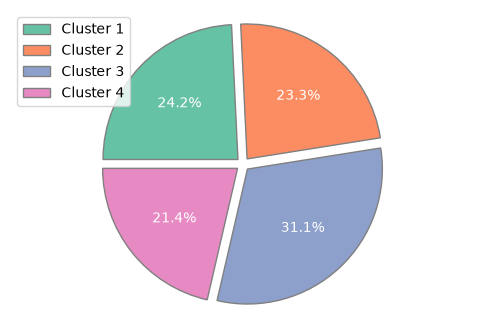

In [46]:
visualize_cluster_distribution(kmean.labels_)

**Phân tích đa biến + kết quả phân cụm**

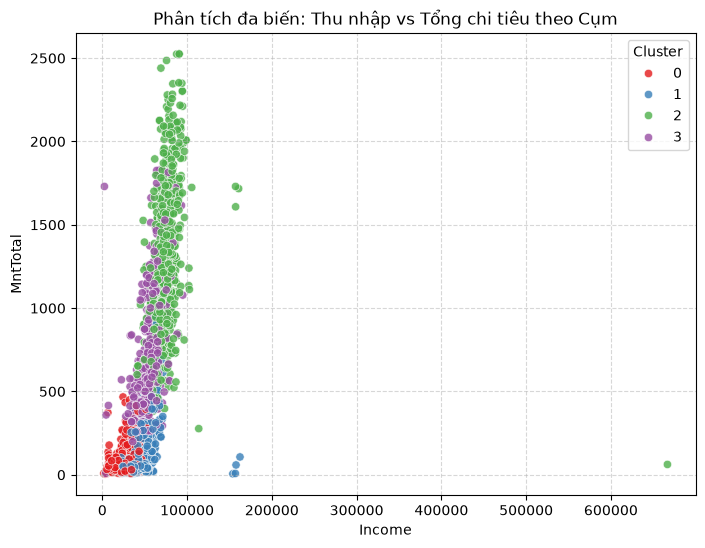

In [47]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=kmean_df, 
    x='Income', 
    y='MntTotal', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.8
)
plt.title('Phân tích đa biến: Thu nhập vs Tổng chi tiêu theo Cụm')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

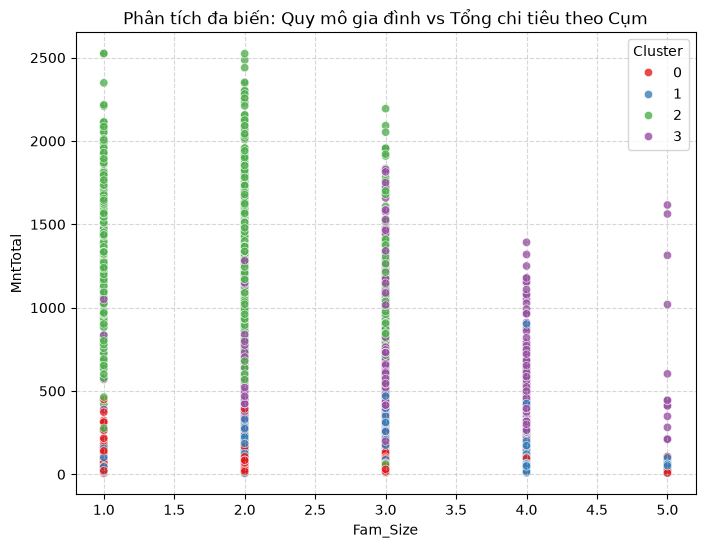

In [48]:
# đặc trưng Fam_Size và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=kmean_df, 
    x='Fam_Size', 
    y='MntTotal', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.8
)
plt.title('Phân tích đa biến: Quy mô gia đình vs Tổng chi tiêu theo Cụm')
plt.xlabel('Fam_Size')
plt.ylabel('MntTotal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

**Phân tích danh mục mua hàng**

Chi tiêu trung bình theo từng danh mục của các cụm:


,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds
Cluster,,,,,,
0,29.287293,6.003683,23.046041,9.160221,5.918969,17.414365
1,69.452975,5.679463,27.172745,7.182342,5.746641,15.389635
2,607.345768,59.294118,405.157819,86.941176,61.119082,73.893831
3,428.826722,23.736952,135.494781,30.778706,24.661795,61.860125


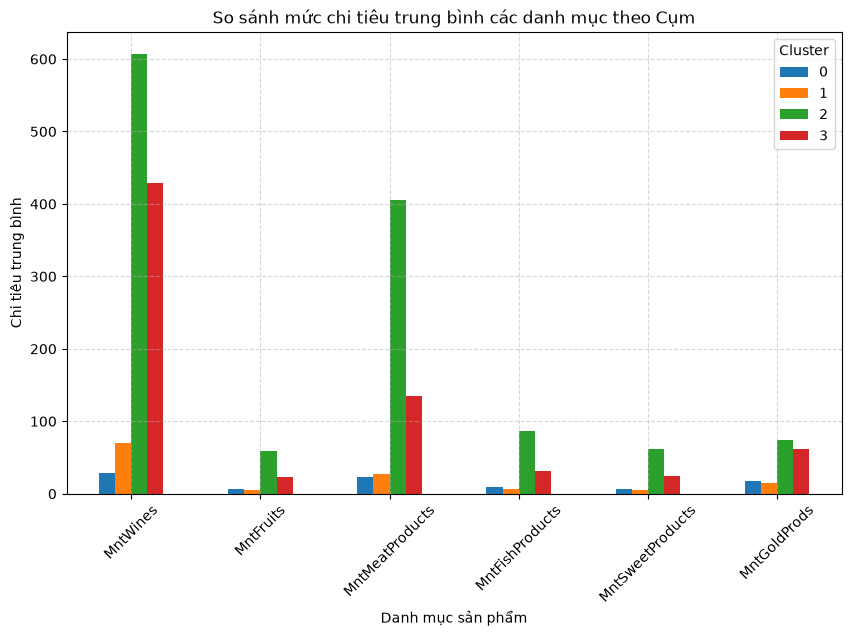

In [49]:
# TODO
mnt_categories = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
cluster_spending = kmean_df.groupby('Cluster')[mnt_categories].mean()

print("Chi tiêu trung bình theo từng danh mục của các cụm:")
display(cluster_spending)

cluster_spending.T.plot(kind='bar', figsize=(10, 6))
plt.title('So sánh mức chi tiêu trung bình các danh mục theo Cụm')
plt.xlabel('Danh mục sản phẩm')
plt.ylabel('Chi tiêu trung bình')
plt.xticks(rotation=45)
plt.legend(title='Cluster')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### A7. Kết hợp PCA và phân cụm
- Biến đổi PCA với số lượng component phù hợp (giữ lại 70-80% thông tin ban đầu).
- Ước lượng số cụm dùng elbow (dùng dữ liệu pca).
- Với số cụm phù hợp, thực hiện phân cụm trên dữ liệu pca.
- Vẽ phân bố kết quả phân cụm.
- Vẽ biểu đồ scatter MntTotal-Income-Cluster.

In [53]:
# vẽ biểu đồ sreeplot
def scree_plot(pca_model, xlabels):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    # explained variance ratio của mô hình pca
    expl_var_ratio = pca_model.explained_variance_ratio_
    # tính cumulative sum của expl_var_ratio (numpy.cumsum)
    expl_var_cumsum = np.cumsum(expl_var_ratio)
    xtick_indx = range(1, len(expl_var_ratio) + 1)
    
    # vẽ các bar thể hiện explained_var
    ax.bar(xtick_indx, expl_var_ratio)
    ax.plot(xtick_indx, expl_var_cumsum, marker='o', color='k')
    
    # set label
    ax.set_xticks(xtick_indx)
    ax.set_xticklabels(xlabels)
    ax.set_xlabel('Principle Components')
    ax.set_ylabel('% variance')
    ax.set_title('Scree Plot')
    
    plt.grid(True)

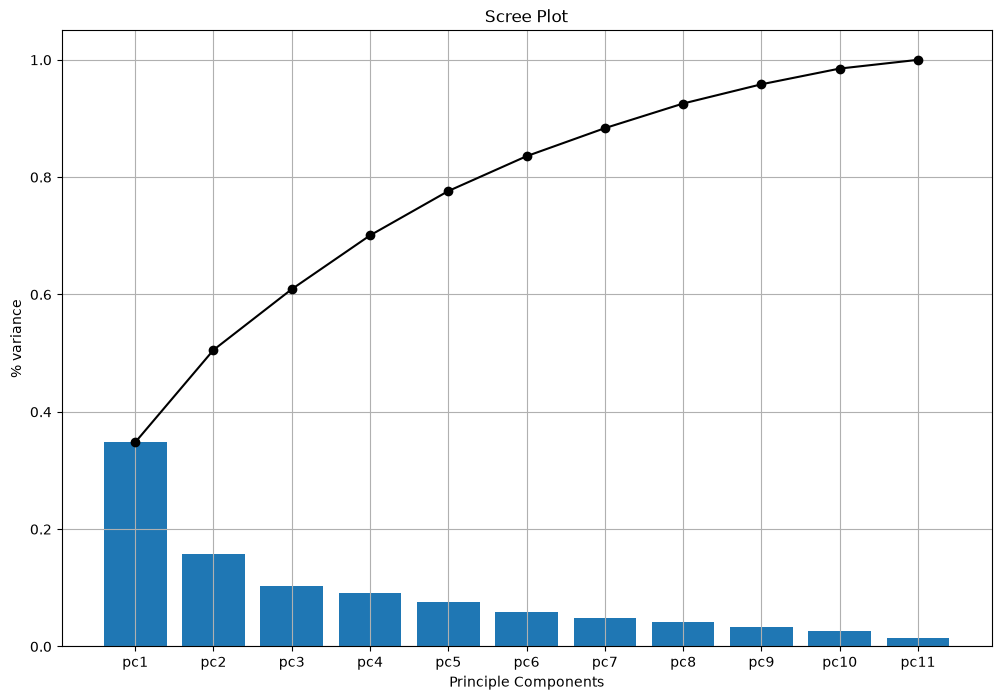

In [55]:
pca_full = PCA()
pca_full.fit(df)
scree_plot(pca_full, [f'pc{i+1}' for i in range(len(df.columns))])

In [56]:
# biến đổi df sang không gian pca 4 chiều
# TODO
pca_4d = PCA(n_components=4)
pca_transformed_4d = pca_4d.fit_transform(df)

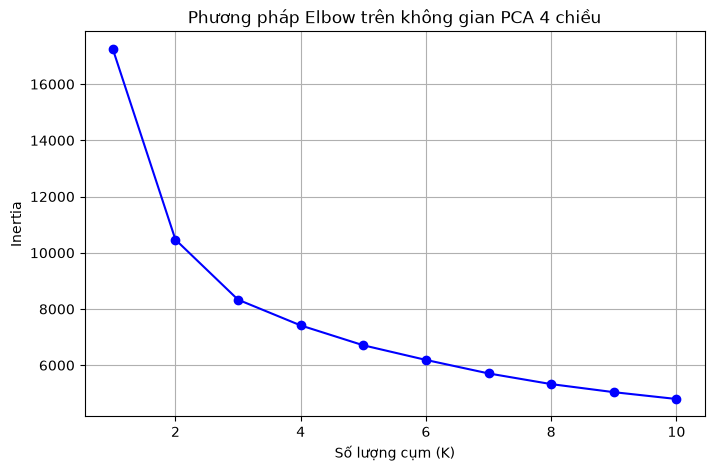

In [59]:
inertias = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, n_init=20, random_state=99)
    km.fit(pca_transformed_4d)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, marker='o', color='b')
plt.xlabel('Số lượng cụm (K)')
plt.ylabel('Inertia')
plt.title('Phương pháp Elbow trên không gian PCA 4 chiều')
plt.grid(True)
plt.show()

In [61]:
model = KMeans(n_init=20, random_state=99)
visualizer = KElbowVisualizer(model, k=10)
visualizer.fit(pca_transformed_4d)
visualizer.show()

NameError: name 'KElbowVisualizer' is not defined

In [62]:
# Gán kết quả phân cụm vào df ban đầu ~ customer_data
kmean_pca_df = customer_data.copy()
kmean_pca_df['Cluster'] = kmean.labels_
kmean_pca_df.head()

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Age,Enroll_days,Fam_Size,Num_Accepted,MntTotal,Cluster
ID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5524,1957,Graduation,1,58138.0,0,0,2012-04-09,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,65,5294,1,0,1617,2
2174,1954,Graduation,1,46344.0,1,1,2014-08-03,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,68,4448,3,0,27,1
4141,1965,Graduation,2,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,57,4795,2,0,776,2
6182,1984,Graduation,2,26646.0,1,0,2014-10-02,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,38,4388,3,0,53,1
5324,1981,PhD,2,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,41,4644,3,0,422,3


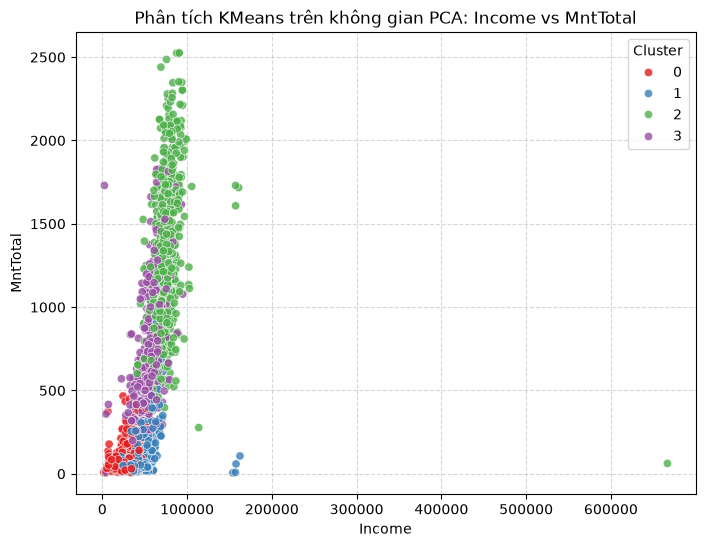

In [63]:
# đặc trưng income và MntTotal: vẽ sns scatterplot với hue là Cluster
# TODO
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=kmean_pca_df, 
    x='Income', 
    y='MntTotal', 
    hue='Cluster', 
    palette='Set1', 
    alpha=0.8
)
plt.title('Phân tích KMeans trên không gian PCA: Income vs MntTotal')
plt.xlabel('Income')
plt.ylabel('MntTotal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

#### A9. Phân tích kết quả phân cụm (DBSCAN)

In [64]:
from sklearn.cluster import DBSCAN

**Sử dụng knee plot để ước lượng eps**

In [65]:
len(df.columns)

11

In [66]:
from sklearn.neighbors import NearestNeighbors
def knee_plot(n_neighs, data):
    neigh = NearestNeighbors(n_neighbors=n_neighs)
    nbrs = neigh.fit(data)
    distances, indices = nbrs.kneighbors(data)

    # plot
    distances = np.sort(distances, axis=0)
    distances = distances[:,1]
    plt.plot(distances)
    
    return distances

**Sử dụng PCA thu giảm số chiều --> phân cụm**

**Chia nhỏ đặc trưng**

In [67]:
sub_df = df[['Income', 'MntTotal', 'Enroll_days']]

### B. Dữ liệu taxi 

In [69]:
import pandas as pd

In [68]:
df = pd.read_csv('data/taxi_data.csv')
df.head()

,LON,LAT,NAME
0,28.17858,-25.73882,11th Street Taxi Rank
1,28.17660,-25.73795,81 Bazaar Street Taxi Rank
2,27.83239,-26.53722,Adams Road Taxi Rank
3,28.12514,-26.26666,Alberton City Mall Taxi Rank
4,28.10144,-26.10567,Alexandra Main Taxi Rank


**Biểu diễn giá trị toạ độ trên bản đồ**

In [74]:
import sys
!{sys.executable} -m pip install folium

Defaulting to user installation because normal site-packages is not writeable
  Using cached folium-0.20.0-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached branca-0.8.2-py3-none-any.whl.metadata (1.7 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached xyzservices-2026.9.1-py3-none-any.whl.metadata (4.1 kB)
Using cached folium-0.20.0-py2.py3-none-any.whl (113 kB)
Using cached branca-0.8.2-py3-none-any.whl (26 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)
Using cached xyzservices-2026.9.1-py3-none-any.whl (98 kB)

   ---------------------------------------- 0/5 [xyzservices]
   ---------------------------------------- 0/5 [xyzservices]
   -------- ------------------------------- 1/5 [MarkupSafe]
   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----------------------- 2/5 [jinja2]
   ---------------- ----

In [75]:
import folium, re

In [78]:
df = df.dropna(subset=['LAT', 'LON'])

X = df[['LAT', 'LON']].values

m = folium.Map(location=[X[:,0].mean(), X[:,1].mean()], tiles='CartoDB positron', zoom_start=10)

C:\Users\MR BAO\AppData\Roaming\Python\Python312\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [79]:
for _,row in df.iterrows():
    folium.CircleMarker(
        location=[row.LAT,row.LON],
        radius=5,
        popup=re.sub(r'\W+',' ',row.NAME),
        fill=True
    ).add_to(m)

# Loại bỏ non-word chars
title = '''<h3 align="center" style="font-size:30px"><b>Given Data</b></h3>'''
m.get_root().html.add_child(folium.Element(title))
m

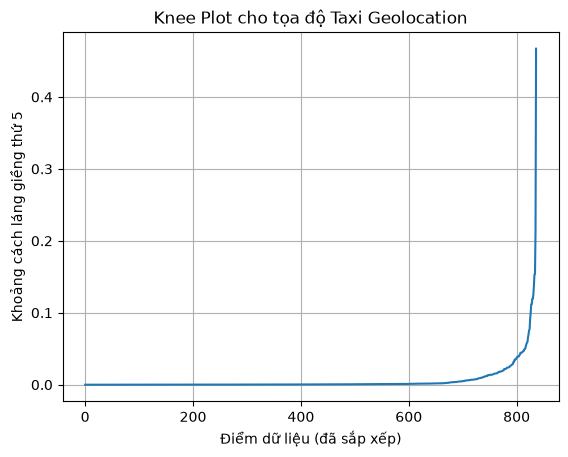

In [82]:
# Knee plot để ước lượng eps
# Gọi hàm knee_plot với số láng giềng k (ví dụ: min_samples = 5)
distances = knee_plot(n_neighs=5, data=X)
plt.title('Knee Plot cho tọa độ Taxi Geolocation')
plt.xlabel('Điểm dữ liệu (đã sắp xếp)')
plt.ylabel('Khoảng cách láng giềng thứ 5')
plt.grid(True)
plt.show()

In [80]:
#First create an array of color schemes
colors = ['royalblue', 'maroon', 'forestgreen', 'mediumorchid', 'tan', 'deeppink', 
          'olive', 'goldenrod', 'lightcyan', 'navy','springgreen','midnightblue',
         'red','brown','limegreen','lime','pink','orchid','crimson','m']*10

In [84]:
# Sử dụng DBSCAN để phân cụm
def create_map(cluster_column, colors_column, title):
    m = folium.Map(
        location=[X[:, 0].mean(), X[:, 1].mean()],
        tiles='CartoDB positron',
        zoom_start=8.5
    )
    for _, row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT, row.LON],
            radius=3,
            popup=f"Cluster: {row[cluster_column]}",
            color=row[colors_column],
            fill=True,
            fill_color=row[colors_column],
            fill_opacity=0.7
        ).add_to(m)
    title_html = f'''
                 <div style="position: fixed; 
                     bottom: 50px; left: 50px; width: 300px; height: 90px; 
                     background-color: white; z-index:9999; font-size:14px;
                     border:2px solid grey; padding: 10px;">
                     {title}
                 </div>
                 '''
    m.get_root().html.add_child(folium.Element(title_html))
    return m

m_clustered = create_map('Cluster', 'Color', '<h3><b>Taxi Clusters (DBSCAN)</b></h3>')
display(m_clustered)

C:\Users\MR BAO\AppData\Roaming\Python\Python312\site-packages\folium\raster_layers.py:130: UserWarning: CartoDB tiles now require an API key. Please provide one to continue using the tiles. You can request the key at https://carto.com/basemaps/apikey/.
  tiles = tiles.build_url(fill_subdomain=False, scale_factor="{r}")  # type: ignore


In [81]:
def create_map(cluster_column, colors_column, title):
    m = folium.Map(location=[X[:,0].mean(),X[:,1].mean()],tiles='Stamen Toner',zoom_start=8.5)
    for _,row in df.iterrows():
        folium.CircleMarker(
            location=[row.LAT,row.LON],
            radius=5,
            popup=row[cluster_column],
            fill=True,
            color=row[colors_column],
            fill_color=row[colors_column],
        ).add_to(m)

    print(title)
    return m